In [1]:
import json

# Load the configuration from the JSON file
with open('/home/omen/Documents/Megha/vit_brain_age/utils/HCCTconfig.json', 'r') as f:
    config = json.load(f)

In [2]:
from model.HCCT import ViTForClassfication 

# Initialize the model with the loaded configuration
model = ViTForClassfication(config=config)

In [3]:
import torch.nn as nn
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = nn.DataParallel(model).to(DEVICE)

In [4]:
checkpoint_path= "/home/omen/Documents/Megha/vit_brain_age/training_output_metricsHCCT_best_model.pth.tar"

model.load_state_dict(torch.load(checkpoint_path)['state_dict']) 
model.to(DEVICE).eval()

/tmp/ipykernel_3588913/1244302475.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path)['state_dict'])


DataParallel(
  (module): ViTForClassfication(
    (embedding): Embeddings(
      (patch_embeddings): PatchEmbeddings(
        (conv_1): ConvBlock(
          (conv): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (bn): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (maxpool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
        (conv_2): ConvBlock(
          (conv): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (bn): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (maxpool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
        (conv_3): ConvBlock(
          (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (bn): BatchNorm3d(128, eps=1e-05, momentum=0.1, affin

In [ ]:
import nibabel as nib
import numpy as np

nii_path = "/home/omen/Documents/Megha/skull_stripped/IXI014-HH-1236-T1_stripped.nii.gz"
img_obj = nib.load(nii_path)
img = img_obj.get_fdata()
affine = img_obj.affine
header = img_obj.header.copy()
DEVICE= 'cpu'

# Normalize and convert to tensor [B, C, D, H, W]
# img = (img - np.mean(img)) / np.std(img)
img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
img_tensor.requires_grad = True

In [46]:
img_tensor.shape

torch.Size([1, 1, 91, 109, 91])

In [7]:
for name, module in model.named_modules():
    print(name)


module
module.embedding
module.embedding.patch_embeddings
module.embedding.patch_embeddings.conv_1
module.embedding.patch_embeddings.conv_1.conv
module.embedding.patch_embeddings.conv_1.bn
module.embedding.patch_embeddings.conv_1.act
module.embedding.patch_embeddings.conv_1.maxpool
module.embedding.patch_embeddings.conv_2
module.embedding.patch_embeddings.conv_2.conv
module.embedding.patch_embeddings.conv_2.bn
module.embedding.patch_embeddings.conv_2.act
module.embedding.patch_embeddings.conv_2.maxpool
module.embedding.patch_embeddings.conv_3
module.embedding.patch_embeddings.conv_3.conv
module.embedding.patch_embeddings.conv_3.bn
module.embedding.patch_embeddings.conv_3.act
module.embedding.patch_embeddings.conv_3.maxpool
module.embedding.patch_embeddings.conv_4
module.embedding.patch_embeddings.conv_4.conv
module.embedding.patch_embeddings.conv_4.bn
module.embedding.patch_embeddings.conv_4.act
module.embedding.patch_embeddings.conv_4.maxpool
module.embedding.patch_embeddings.conv_5


In [8]:
from captum.attr import LayerGradCam

# Choose final conv layer in DenseNet201 (last layer in last dense block)
target_layer = model.module.embedding.patch_embeddings.conv_5

gradcam = LayerGradCam(model, target_layer)

# Get Grad-CAM attribution for regression output
attribution = gradcam.attribute(img_tensor, target=0)
attr_map = attribution.squeeze().detach().cpu().numpy()

/home/omen/anaconda3/envs/vit_brain_age/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import torch.nn.functional as F

# attribution shape: [1, 1, D', H', W']
# Upsample to match input shape
upsampled_attr = F.interpolate(
    attribution, size=img_tensor.shape[2:], mode='trilinear', align_corners=False
).squeeze().detach().cpu().numpy()

In [10]:
upsampled_attr.shape

(91, 109, 91)

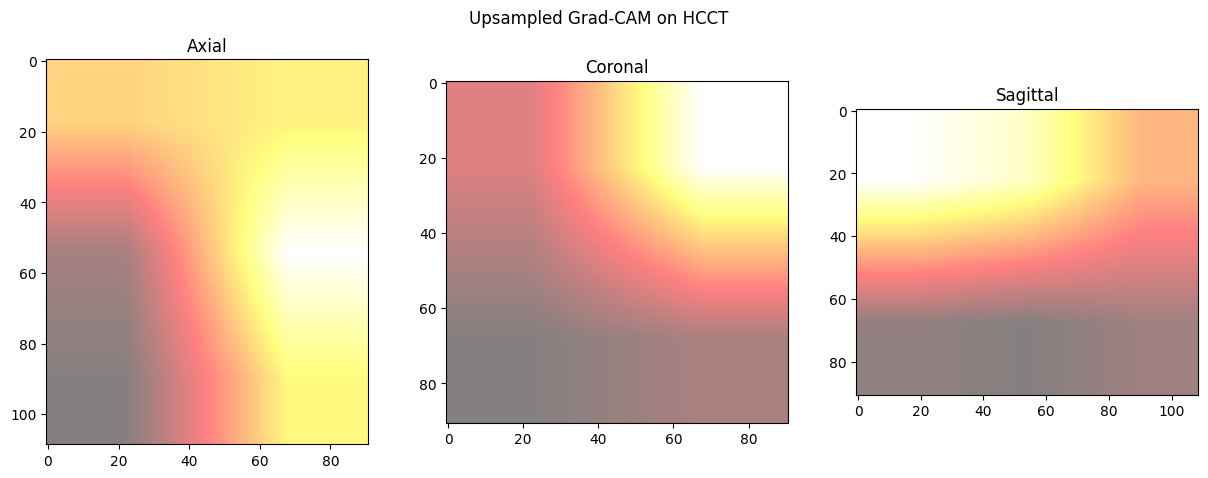

In [11]:
# only HeatMap

import matplotlib.pyplot as plt

# raw_img: already shape (D, H, W)
attr_map = upsampled_attr

# Get center slices
z, y, x = [s // 2 for s in attr_map.shape]

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(attr_map[z], cmap='hot', alpha=0.5)
plt.title("Axial")

plt.subplot(1,3,2)
plt.imshow(attr_map[:, y, :], cmap='hot', alpha=0.5)
plt.title("Coronal")

plt.subplot(1,3,3)
plt.imshow(attr_map[:, :, x], cmap='hot', alpha=0.5)
plt.title("Sagittal")

plt.suptitle("Upsampled Grad-CAM on HCCT")
plt.show()


In [12]:
upsampled_attr.shape

(91, 109, 91)

In [13]:
gradcam_nifti = nib.Nifti1Image(upsampled_attr, affine=affine, header=header)
nib.save(gradcam_nifti, '/home/omen/Documents/Megha/vit_brain_age/training_output_metrics/gradcam_overlay.nii.gz')

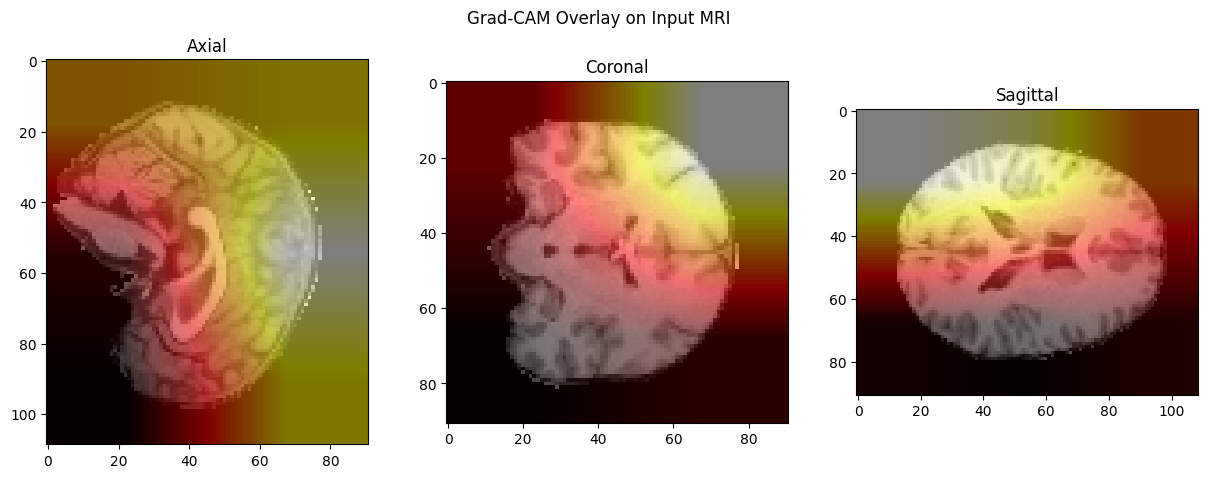

In [14]:
# overlayyed

import matplotlib.pyplot as plt

# Pick center slice for each axis
z, y, x = [s // 2 for s in img.shape]

plt.figure(figsize=(15, 5))

# Axial view
plt.subplot(1, 3, 1)
plt.imshow(img[z], cmap='gray')
plt.imshow(upsampled_attr[z], cmap='hot', alpha=0.5)
plt.title("Axial")

# Coronal view
plt.subplot(1, 3, 2)
plt.imshow(img[:, y, :], cmap='gray')
plt.imshow(upsampled_attr[:, y, :], cmap='hot', alpha=0.5)
plt.title("Coronal")

# Sagittal view
plt.subplot(1, 3, 3)
plt.imshow(img[:, :, x], cmap='gray')
plt.imshow(upsampled_attr[:, :, x], cmap='hot', alpha=0.5)
plt.title("Sagittal")

plt.suptitle("Grad-CAM Overlay on Input MRI")
plt.show()


# Attention maps

In [1]:
import json

# Load the configuration from the JSON file
with open('/home/omen/Documents/Megha/vit_brain_age/utils/HCCTconfig.json', 'r') as f:
    config = json.load(f)

In [2]:
from model.HCCT import ViTForClassfication 

# Initialize the model with the loaded configuration
model = ViTForClassfication(config=config)

In [3]:
import torch.nn as nn
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = nn.DataParallel(model).to(DEVICE)

In [4]:
checkpoint_path= "/home/omen/Documents/Megha/vit_brain_age/training_output_metricsHCCT_best_model.pth.tar"

model.load_state_dict(torch.load(checkpoint_path)['state_dict']) 
model.to(DEVICE).eval()

/tmp/ipykernel_574757/1244302475.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path)['state_dict'])


DataParallel(
  (module): ViTForClassfication(
    (embedding): Embeddings(
      (patch_embeddings): PatchEmbeddings(
        (conv_1): ConvBlock(
          (conv): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (bn): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (maxpool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
        (conv_2): ConvBlock(
          (conv): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (bn): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (maxpool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
        (conv_3): ConvBlock(
          (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (bn): BatchNorm3d(128, eps=1e-05, momentum=0.1, affin

In [5]:
import nibabel as nib
import numpy as np

nii_path = "/home/omen/Documents/Megha/skull_stripped/IXI002-Guys-0828-T1_stripped.nii.gz"
img_obj = nib.load(nii_path)
img = img_obj.get_fdata()
affine = img_obj.affine
header = img_obj.header.copy()

In [6]:
import torch
img_tensor = torch.tensor(img, dtype=torch.float32)
img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)
img_tensor.shape

torch.Size([1, 1, 91, 109, 91])

In [7]:
output = model(img_tensor, output_attentions=True)

In [8]:
age, att_prob= output

Attention map corresponding to transformer block  1


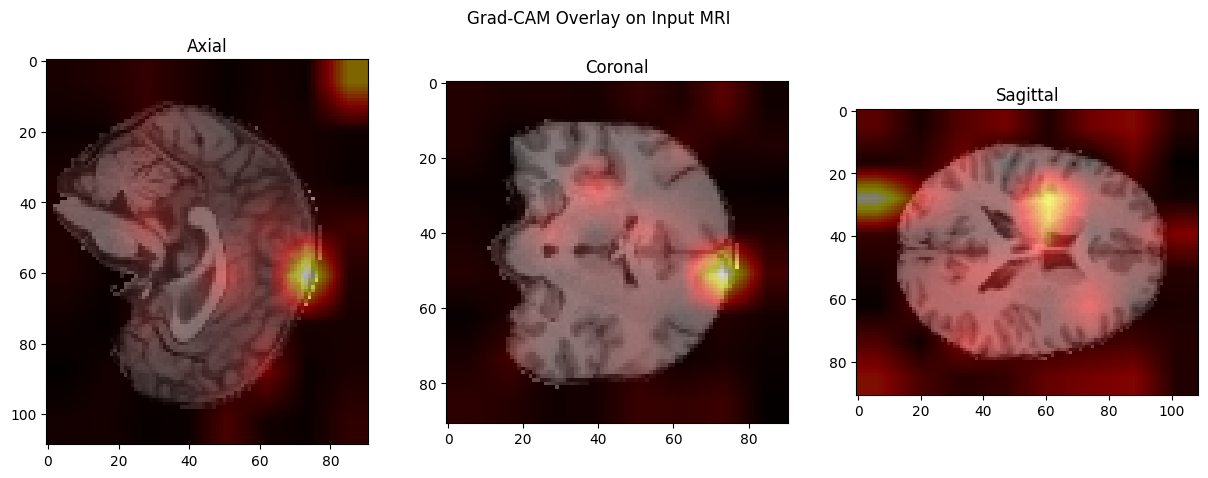

Attention map corresponding to transformer block  2


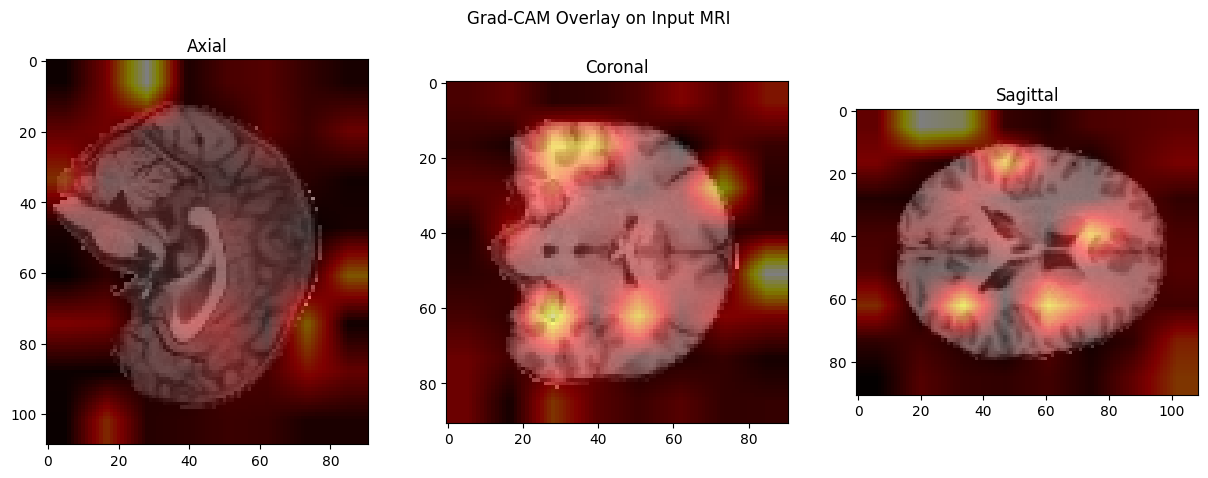

Attention map corresponding to transformer block  3


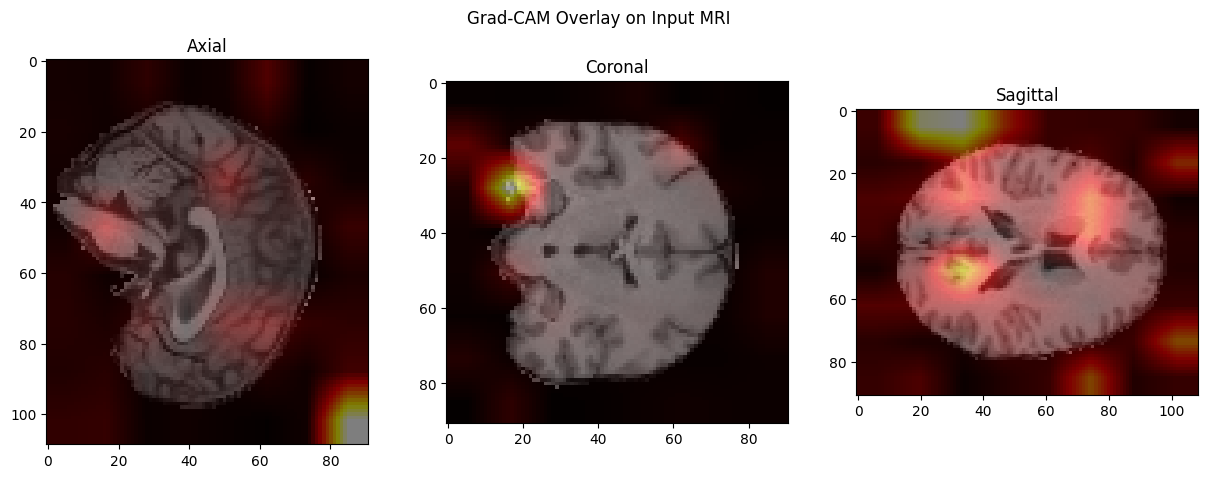

In [9]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

for i in range(len(att_prob)):

    attn_prob= att_prob[i]

    # Step 1: Extract CLS token attention to all other tokens
    # Shape becomes [1, 8, 512]
    cls_attn = attn_prob[:, :, 0, 1:]

    # Step 2: Average over attention heads → shape: [1, 512]
    cls_attn_mean = cls_attn.mean(dim=1)

    # Step 3: Reshape to 3D grid (8 x 8 x 8)
    attn_3d = cls_attn_mean.view(1, 1, 8, 8, 8)  # [B, C, D, H, W]

    # Step 4: Interpolate to original shape [91, 109, 91]
    # Mode: 'trilinear' for 3D
    attn_upsampled = F.interpolate(attn_3d, size=(91, 109, 91), mode='trilinear', align_corners=False)

    # Step 5: Normalize the attention map for visualization
    attn_norm = (attn_upsampled - attn_upsampled.min()) / (attn_upsampled.max() - attn_upsampled.min())

    # Step 6: Convert to numpy for visualization or saving
    attn_map_np = attn_norm.squeeze().detach().cpu().numpy()  # shape: (91, 109, 91)

    # Optional: Visualize a middle slice in each plane
    print("Attention map corresponding to transformer block ", i+1)
    z, y, x = [s // 2 for s in img.shape]
    # z, y, x = 20, 30, 20

    plt.figure(figsize=(15, 5))

    # Axial view
    plt.subplot(1, 3, 1)
    plt.imshow(img[z], cmap='gray')
    plt.imshow(attn_map_np[z], cmap='hot', alpha=0.5)
    plt.title("Axial")

    # Coronal view
    plt.subplot(1, 3, 2)
    plt.imshow(img[:, y, :], cmap='gray')
    plt.imshow(attn_map_np[:, y, :], cmap='hot', alpha=0.5)
    plt.title("Coronal")

    # Sagittal view
    plt.subplot(1, 3, 3)
    plt.imshow(img[:, :, x], cmap='gray')
    plt.imshow(attn_map_np[:, :, x], cmap='hot', alpha=0.5)
    plt.title("Sagittal")

    plt.suptitle("Grad-CAM Overlay on Input MRI")
    plt.show()

In [19]:
attn_map_np.shape

(91, 109, 91)

# Occlusion using captum

In [47]:
from captum.attr import Occlusion
import torch

# Your input tensor
img_tensor.requires_grad_(True)

# Initialize the model (ensure it's in eval mode)
model.eval()

# Define a wrapper around the model's forward to only return scalar output
def forward_fn(input):
    # input shape: [1, 1, 91, 109, 91]
    output = model(input, output_attentions=False)
    # Output: [1, 1], we return a scalar (e.g., first item of batch)
    return output.item()  # assuming regression output

# Define occlusion object
occlusion = Occlusion(forward_fn)

# Set sliding window shape and strides (experiment based on resolution and volume)
sliding_window_shape = (1, 6, 6, 6)  # occlude cubes of shape 9x9x9
strides = (1, 6, 6, 6)  # how much to shift the window

# Compute attribution
attributions = occlusion.attribute(
    inputs=img_tensor,
    strides=strides,
    sliding_window_shapes=sliding_window_shape,
    baselines=0  # by default replaces occluded patch with 0
)

# `attributions` has the same shape as `x`: [1, 1, 91, 109, 91]


In [48]:
attributions.shape

torch.Size([1, 1, 91, 109, 91])

In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

# Assuming 'attributions' is a tensor of shape [1, 1, 91, 109, 91]
# Step 0: Convert to 3D numpy array
attr_3d = attributions[0, 0].detach().cpu().numpy()  # shape: [91, 109, 91]

# Step 1: Normalize to [0, 1]
attr_3d = (attr_3d - np.min(attr_3d)) / (np.max(attr_3d) - np.min(attr_3d))

# Step 2: Apply 3D Gaussian smoothing
smoothed_attr = scipy.ndimage.gaussian_filter(attr_3d, sigma=2)

In [50]:
smoothed_attr= torch.tensor(smoothed_attr).unsqueeze(0).unsqueeze(0)
smoothed_attr.shape

torch.Size([1, 1, 91, 109, 91])

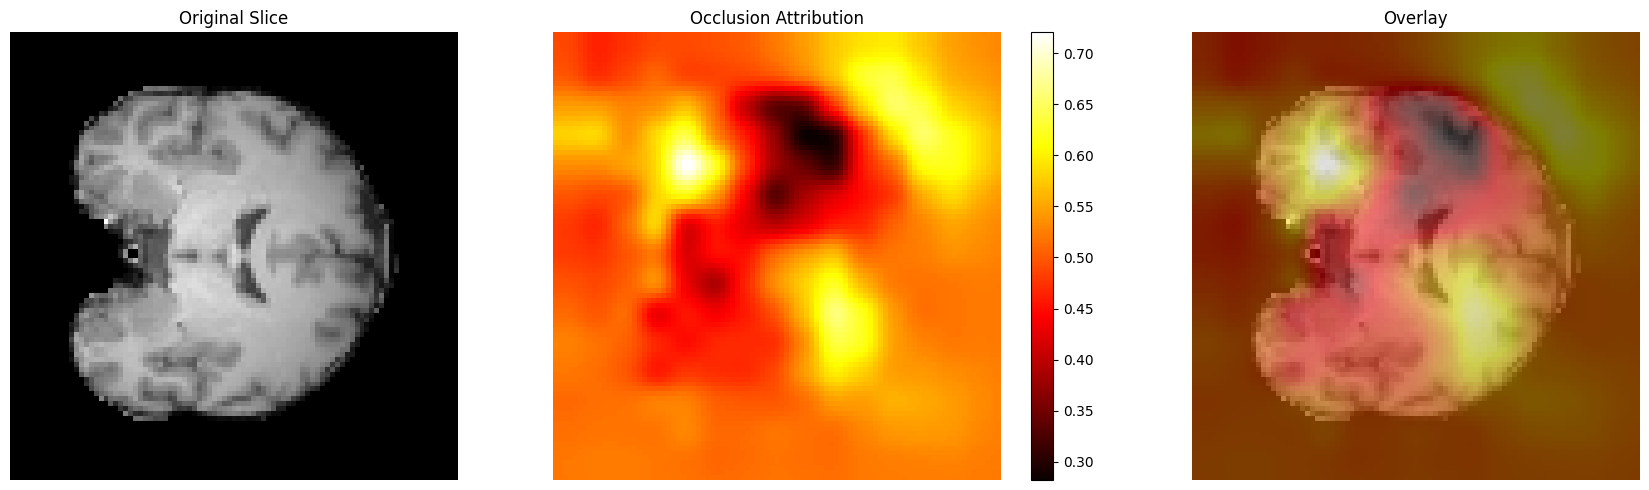

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Choose a slice
slice_idx = 60

# Extract slices
attr_slice = smoothed_attr[0, 0, :, slice_idx, :].detach().cpu().numpy()
input_slice = img_tensor[0, 0, :, slice_idx, :].detach().cpu().numpy()

# Normalize input image for better visualization
input_norm = (input_slice - np.min(input_slice)) / (np.max(input_slice) - np.min(input_slice))

# Plot
plt.figure(figsize=(18, 5))

# Original MRI slice
plt.subplot(1, 3, 1)
plt.title("Original Slice")
plt.imshow(input_norm, cmap='gray')
plt.axis('off')

# Occlusion Attribution
plt.subplot(1, 3, 2)
plt.title("Occlusion Attribution")
plt.imshow(attr_slice, cmap='hot')
plt.colorbar()
plt.axis('off')

# Overlay: original + attribution
plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(input_norm, cmap='gray')
plt.imshow(attr_slice, cmap='hot', alpha=0.5)  # 0.5 = 50% transparency
plt.axis('off')

plt.tight_layout()
plt.show()


In [52]:
smoothed_attr = smoothed_attr.squeeze().squeeze()

In [53]:
occlusion_nifti = nib.Nifti1Image(smoothed_attr, affine=affine, header=header)
nib.save(occlusion_nifti, '/home/omen/Documents/Megha/vit_brain_age/training_output_metrics/occlusion_overlay.nii.gz')